training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


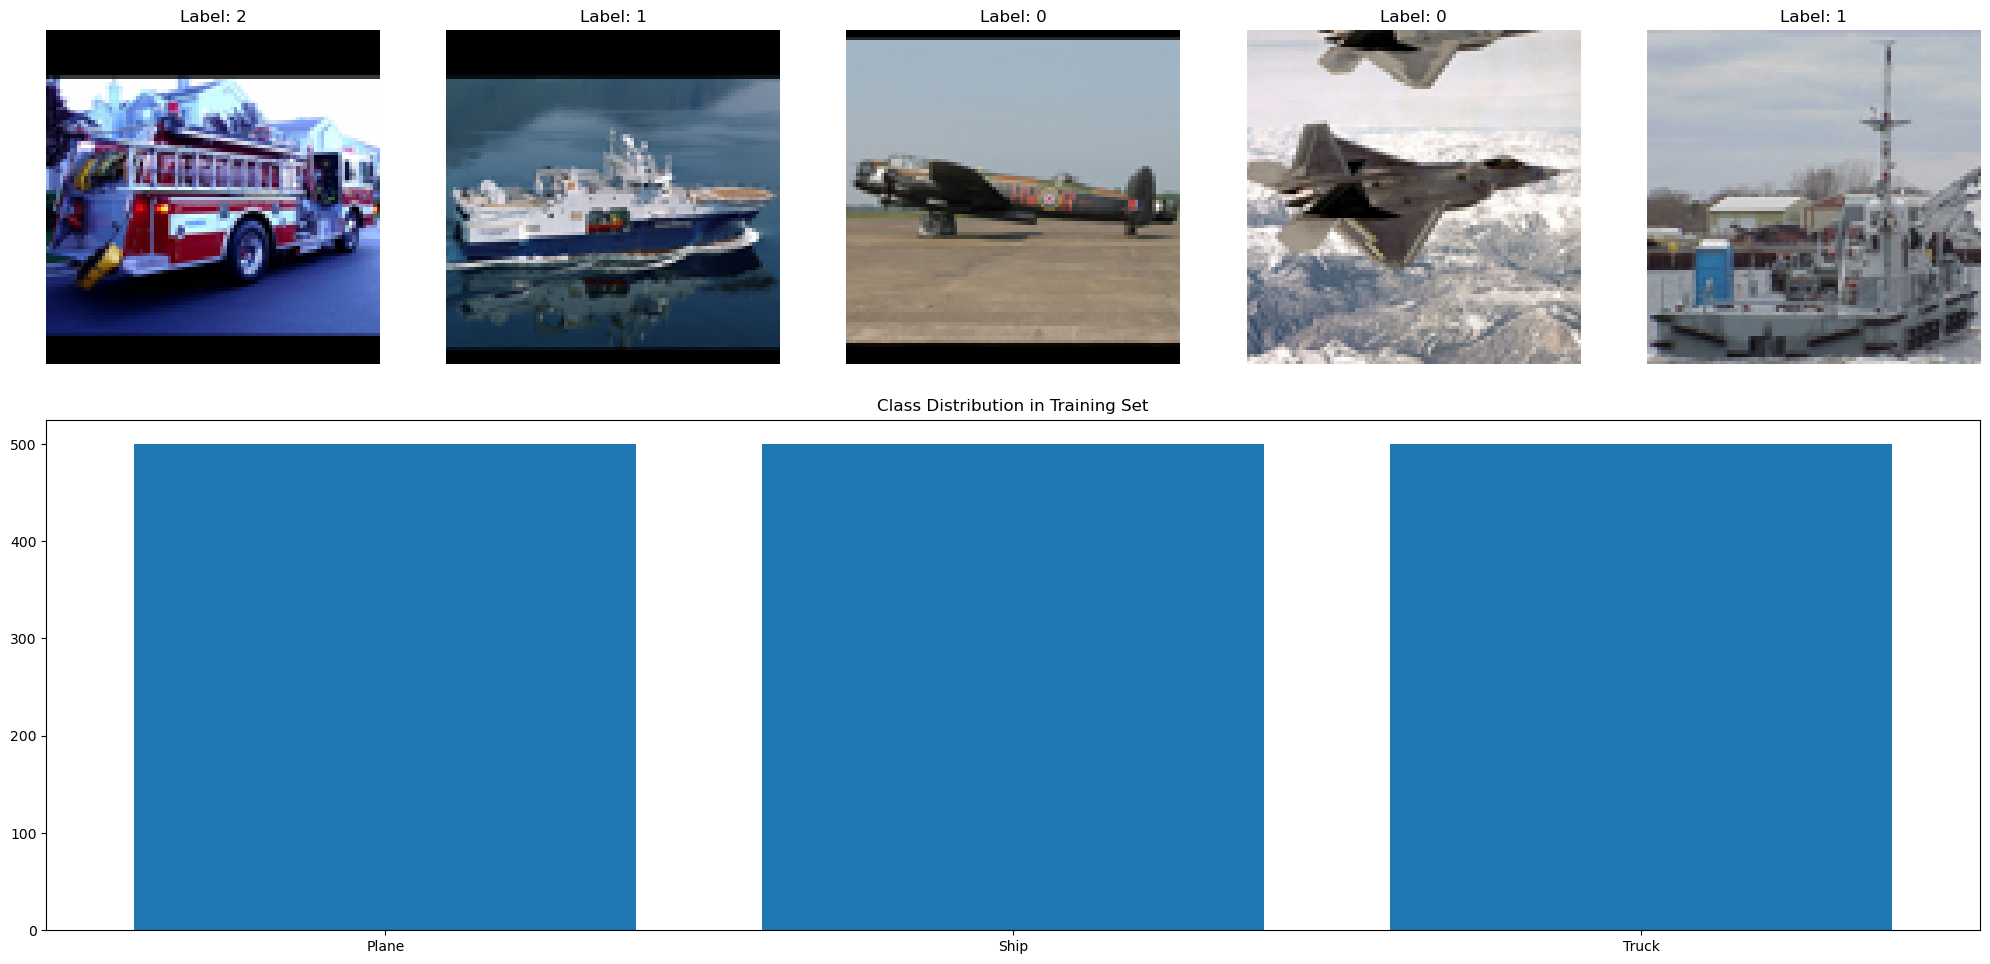

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


In [3]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset

# Create datasets
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Create loaders
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,           #  Shuffles training data each epoch
        pin_memory=True         #  Speeds up transfer to GPU (if using CUDA)
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,          #  Keeps validation consistent across epochs
        pin_memory=True         #  Still helpful for val on GPU
    )
}




=== Training: VGG11BN_2a_no_dropout ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.3467

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.6233

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7933

Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.8067

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.9000
Total training time: 320.76 seconds


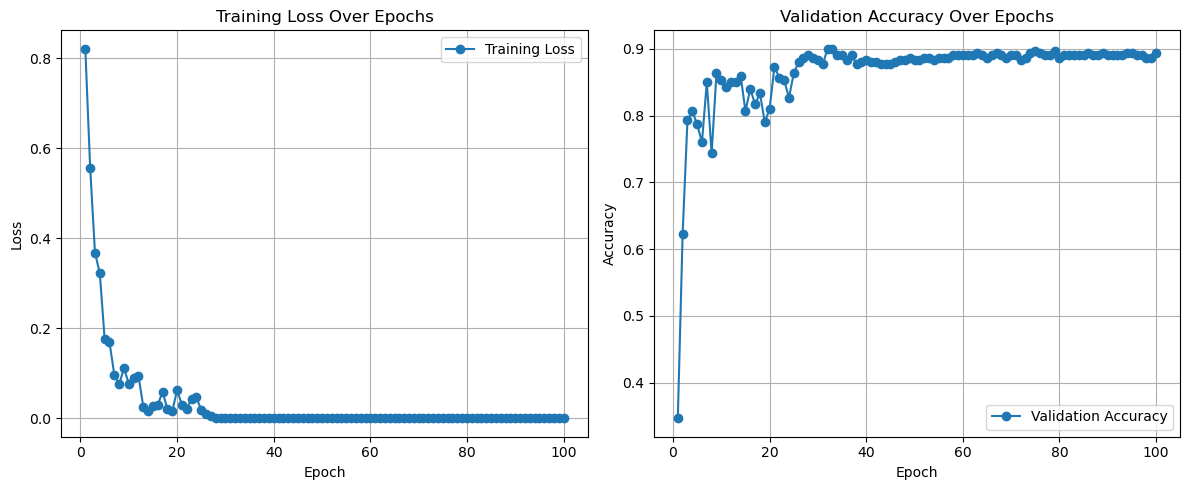

              precision    recall  f1-score   support

       Plane       0.93      0.88      0.90       100
        Ship       0.89      0.85      0.87       100
       Truck       0.86      0.95      0.90       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.7563, Validation Accuracy: 0.8933 |
+------------------------------------------------------+


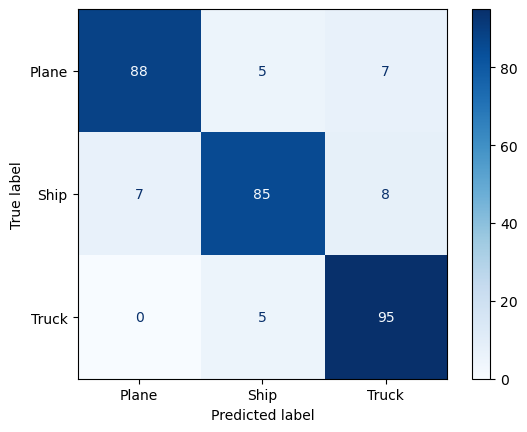

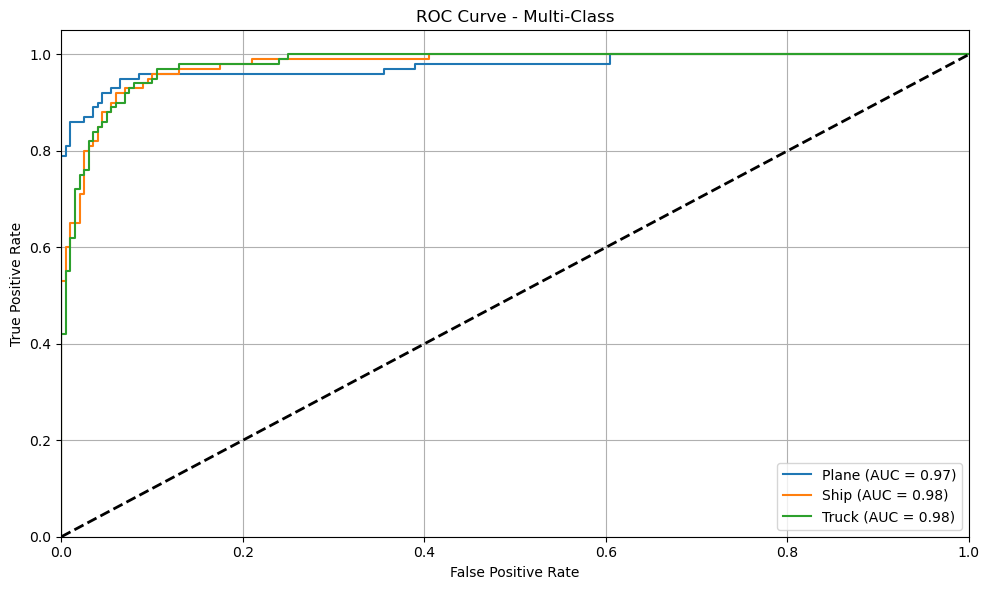

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout.png


=== Training: VGG11BN_2a_no_dropout_weightdecay ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.4867

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.6833

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7333

Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.7867

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8967
Total training time: 325.69 seconds


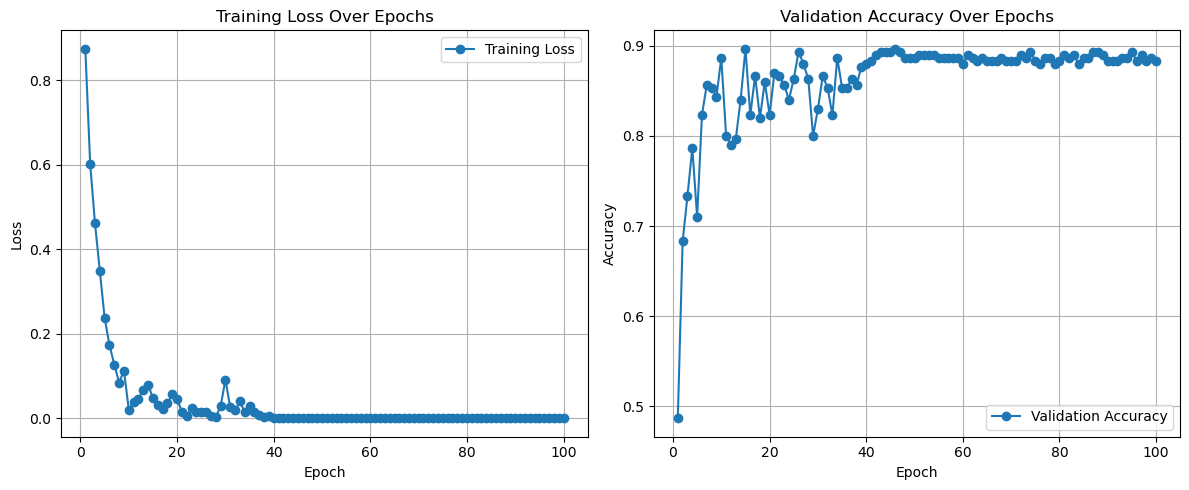

              precision    recall  f1-score   support

       Plane       0.93      0.89      0.91       100
        Ship       0.87      0.85      0.86       100
       Truck       0.86      0.91      0.88       100

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.6369, Validation Accuracy: 0.8833 |
+------------------------------------------------------+


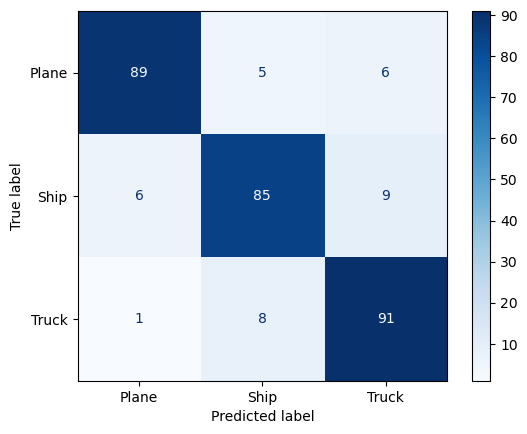

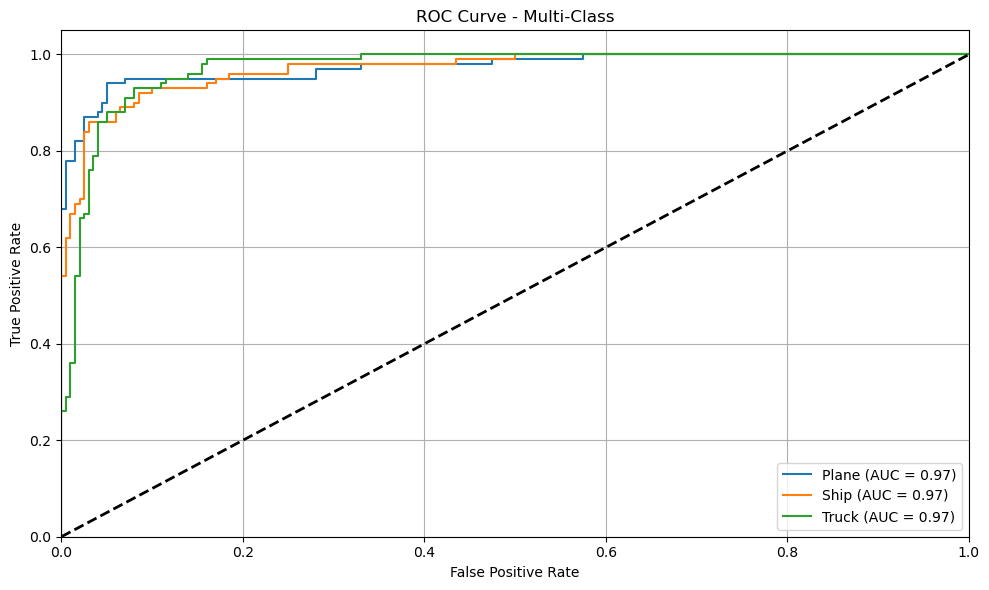

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay.png


=== Training: VGG11BN_2a_no_dropout_weightdecay_scheduler ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.3633

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.7000

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.8200

Epoch 4/100
----------



Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8867
Total training time: 326.49 seconds


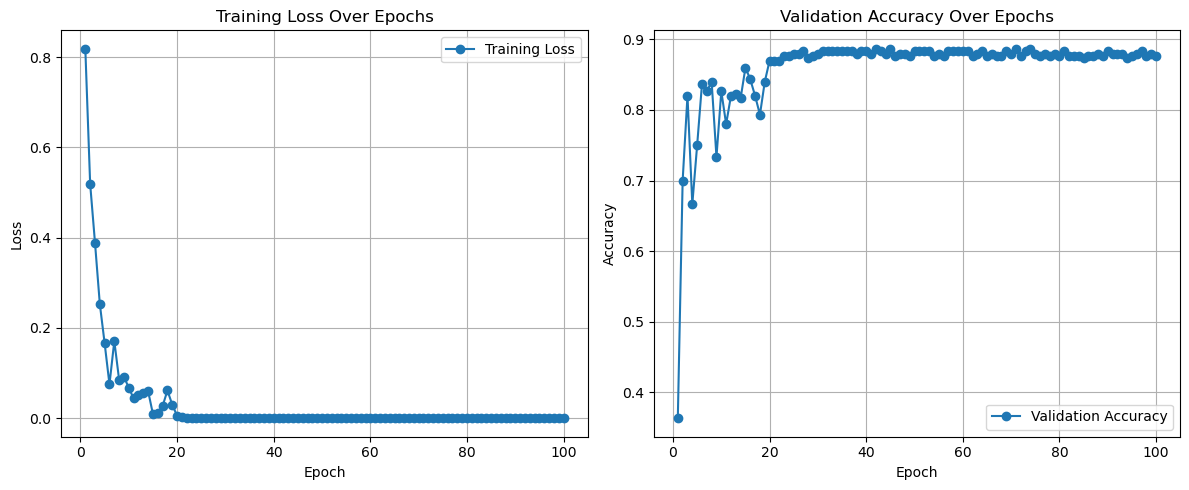

              precision    recall  f1-score   support

       Plane       0.93      0.90      0.91       100
        Ship       0.85      0.86      0.86       100
       Truck       0.85      0.87      0.86       100

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.7500, Validation Accuracy: 0.8767 |
+------------------------------------------------------+


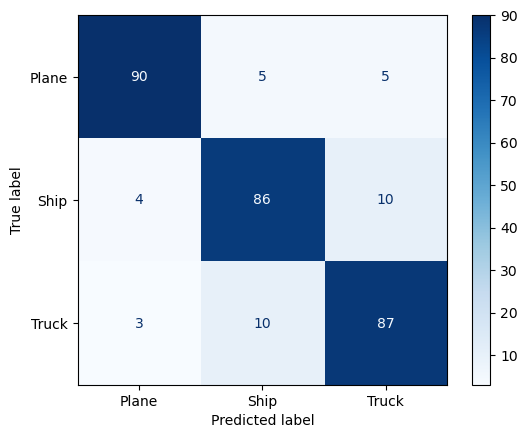

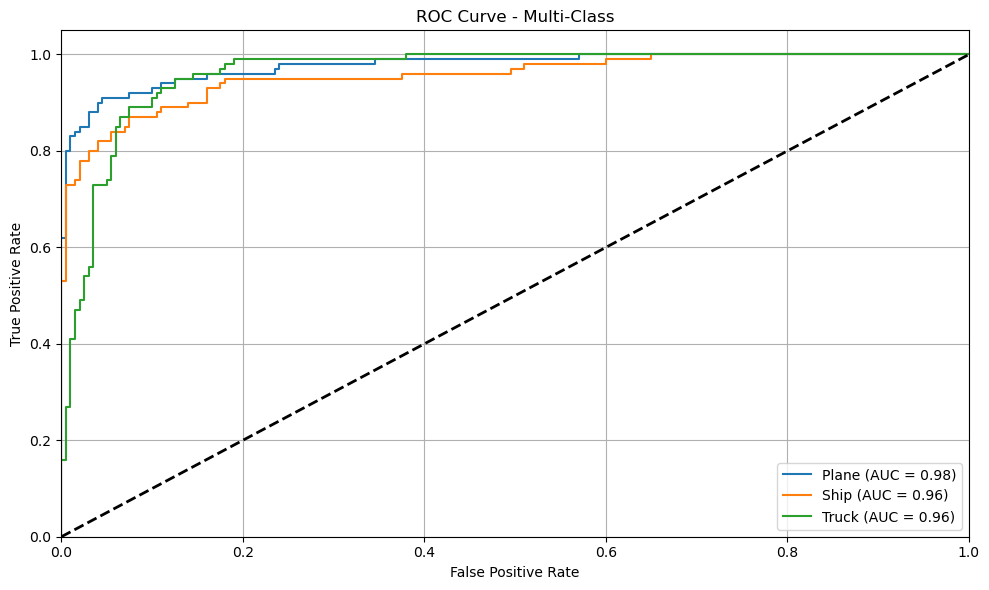

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2a_no_dropout_weightdecay_scheduler.png


=== Training: VGG11BN_2c_with_dropout ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.4067

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.7233

Epoch 3/100
----------



Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.7700

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.9000
Total training time: 319.85 seconds


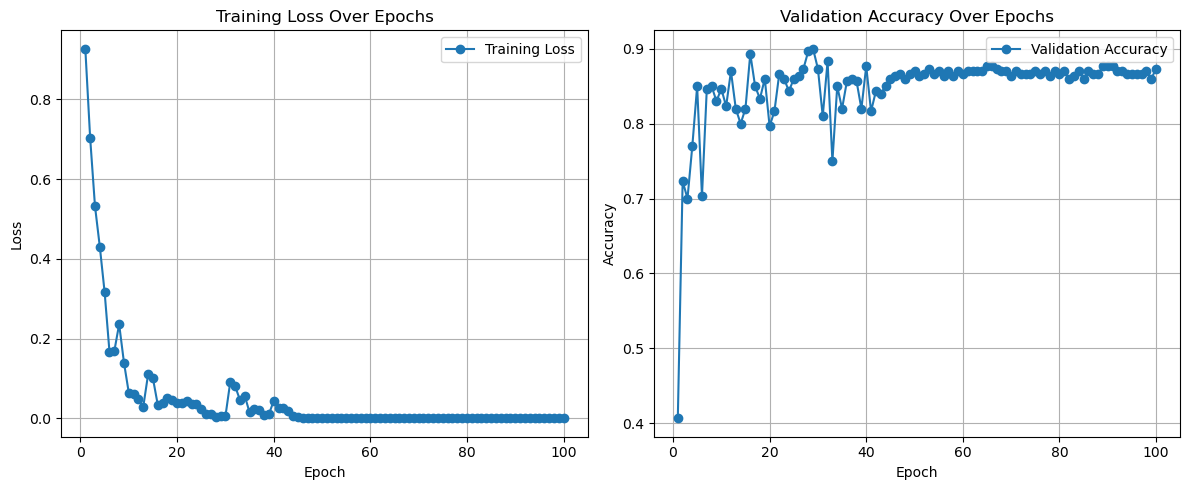

              precision    recall  f1-score   support

       Plane       0.90      0.90      0.90       100
        Ship       0.88      0.82      0.85       100
       Truck       0.84      0.90      0.87       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.9845, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


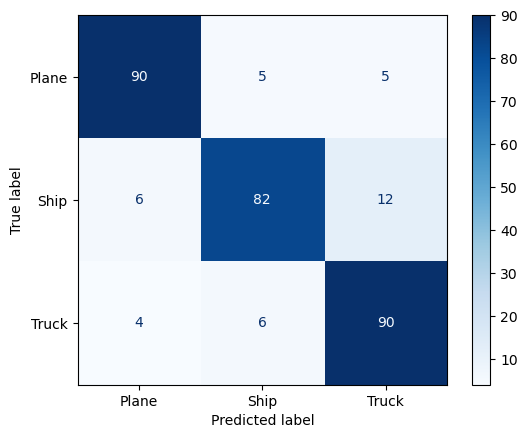

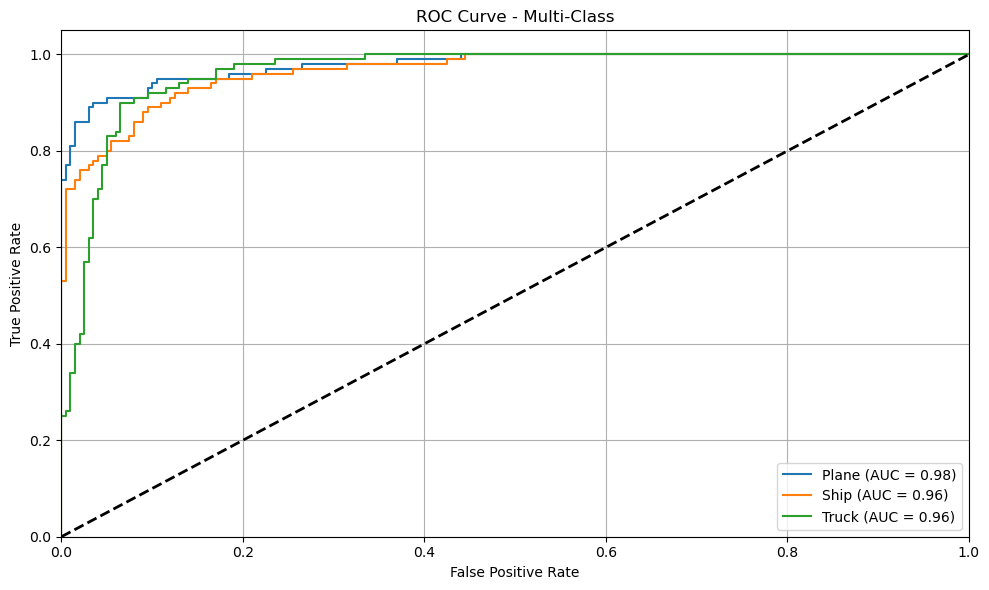

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout.png


=== Training: VGG11BN_2c_with_dropout_weightdecay ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.5200

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.7833

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7867

Epoch 4/100
----------



Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8967
Total training time: 316.25 seconds


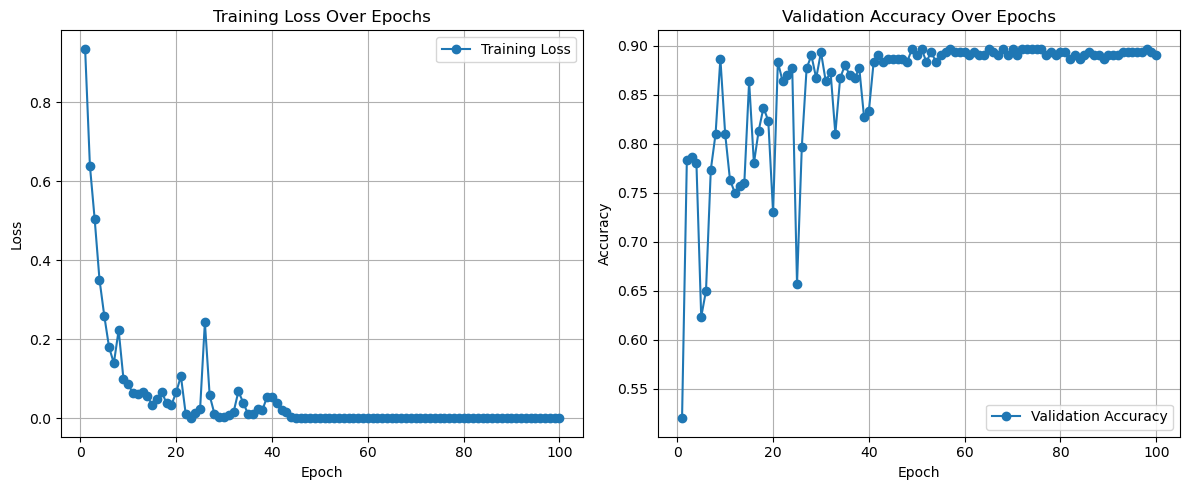

              precision    recall  f1-score   support

       Plane       0.93      0.90      0.91       100
        Ship       0.91      0.86      0.88       100
       Truck       0.84      0.91      0.88       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300

+------------------------------------------------------+
| Validation Loss: 0.6421, Validation Accuracy: 0.8900 |
+------------------------------------------------------+


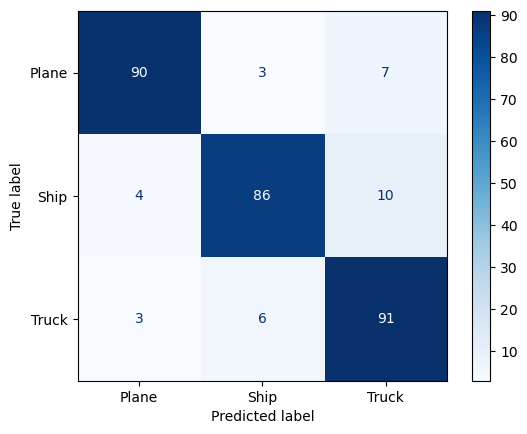

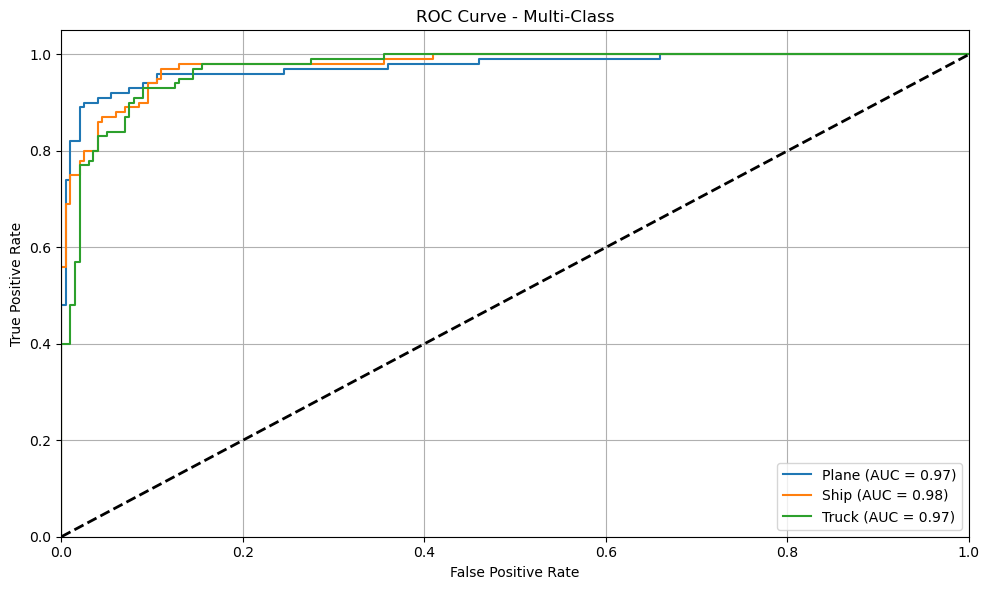

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.5233

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.7367

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7833

Epoch 4/100
----------



Epoch 5/100
----------


...


Epoch 67/100
----------



Epoch 68/100
----------



Epoch 69/100
----------



Epoch 70/100
----------


Train Epoch 70:  95%|█████████▍| 36/38 [00:02<00:00, 11.68it/s, acc=1.0000, loss=0.0000]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [4]:
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_multiclass_roc
from src.utils import set_seed, print_framed_metrics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define experiment configurations
configs = [
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True
    },
]

# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} ===")

    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=cfg["weight_decay"])

    scheduler = StepLR(optimizer, step_size=20, gamma=0.5) if cfg["use_scheduler"] else None

    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=cfg["name"]
    )


    # Evaluation
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    # Confusion matrix
    plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'], save_path=f"plots/{cfg['name']}_confusion_matrix.png")
    
    plot_multiclass_roc(
    model=trained_model,
    dataloader=dataloaders['val'],
    device=device,
    num_classes=3,
    class_names=['Plane', 'Ship', 'Truck'],
    model_name=cfg["name"]
    )


In [5]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset

# Create datasets
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Create loaders
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,           #  Shuffles training data each epoch
        pin_memory=True         #  Speeds up transfer to GPU (if using CUDA)
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False,          #  Keeps validation consistent across epochs
        pin_memory=True         #  Still helpful for val on GPU
    )
}




=== Training: VGG11BN_2a_no_dropout ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.5000

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.5267

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7233

Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.8200

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8900
Total training time: 245.97 seconds


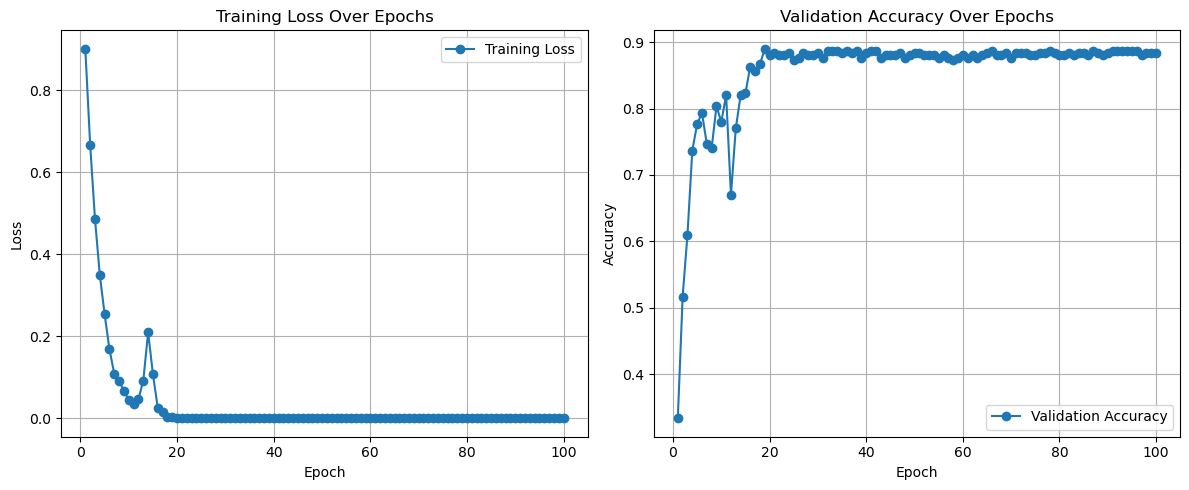

              precision    recall  f1-score   support

       Plane       0.94      0.89      0.91       100
        Ship       0.86      0.87      0.87       100
       Truck       0.86      0.89      0.87       100

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.7322, Validation Accuracy: 0.8833 |
+------------------------------------------------------+


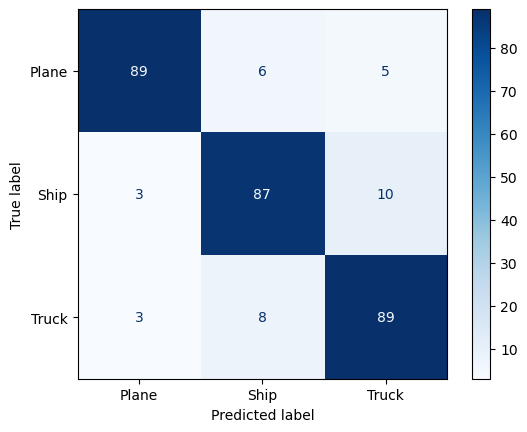

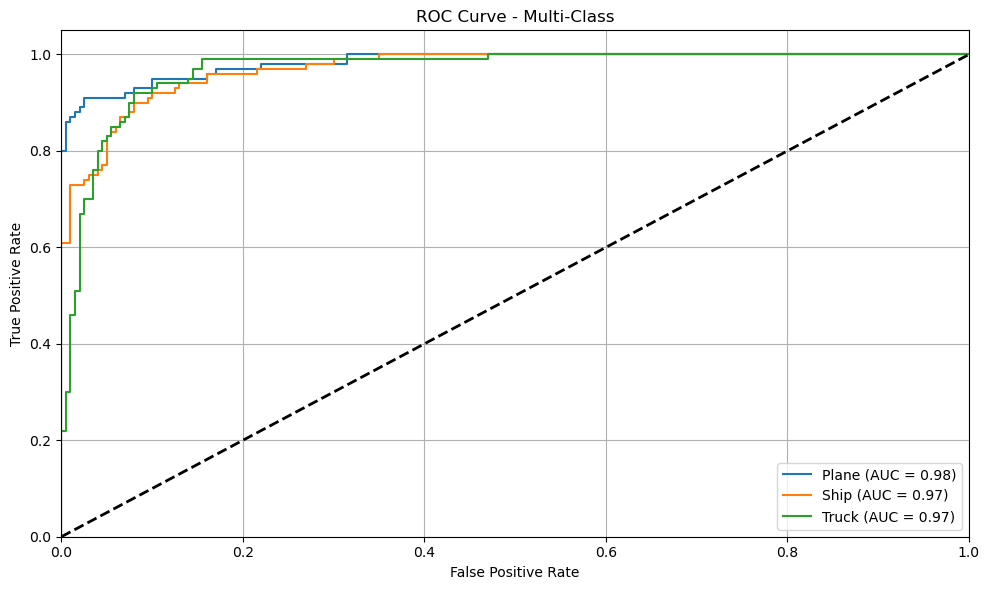

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout.png


=== Training: VGG11BN_2c_with_dropout_weightdecay ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.3333

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.5033

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7133

Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.8533

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8867
Total training time: 250.69 seconds


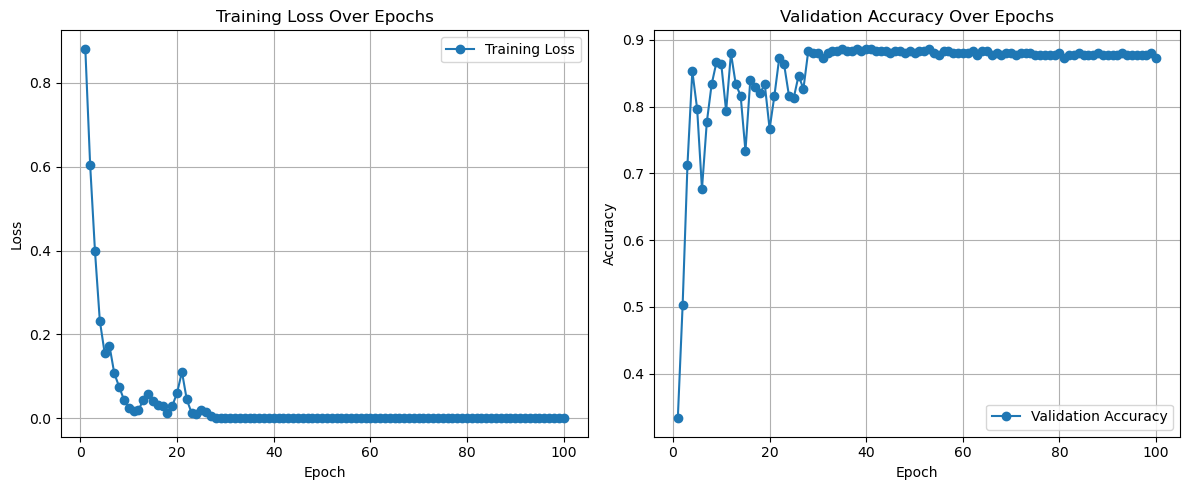

              precision    recall  f1-score   support

       Plane       0.94      0.88      0.91       100
        Ship       0.86      0.86      0.86       100
       Truck       0.83      0.88      0.85       100

    accuracy                           0.87       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.88      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.5729, Validation Accuracy: 0.8733 |
+------------------------------------------------------+


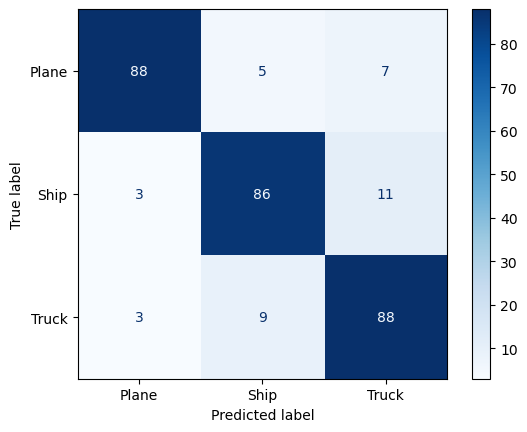

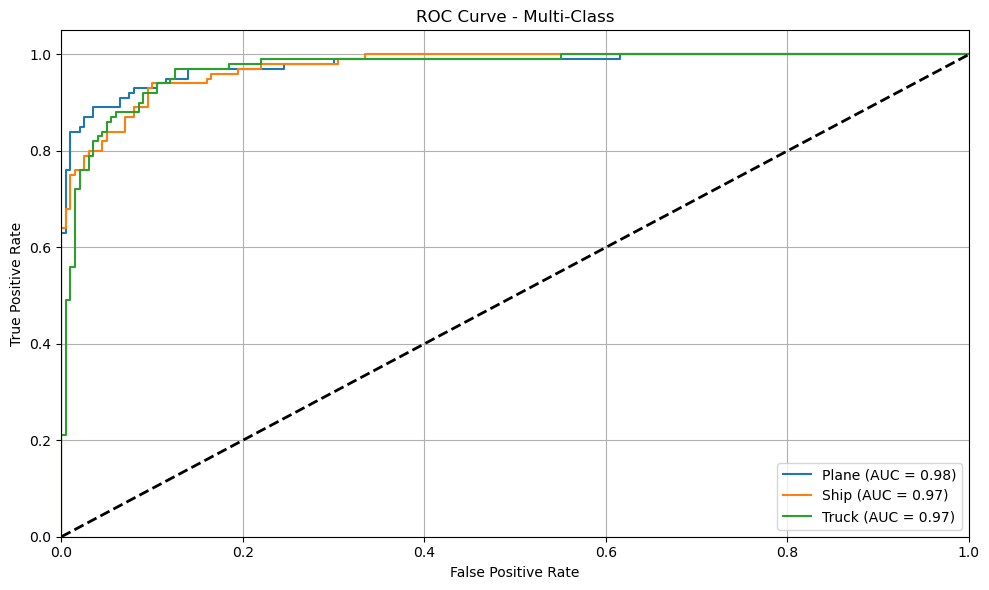

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay.png


=== Training: VGG11BN_2c_with_dropout_weightdecay_scheduler ===
Epoch 1/100
----------


New best model found at epoch 1 with accuracy 0.4567

Epoch 2/100
----------


New best model found at epoch 2 with accuracy 0.4867

Epoch 3/100
----------


New best model found at epoch 3 with accuracy 0.7467

Epoch 4/100
----------


New best model found at epoch 4 with accuracy 0.8100

Epoch 5/100
----------


...


Epoch 97/100
----------



Epoch 98/100
----------



Epoch 99/100
----------



Epoch 100/100
----------



Best val Acc: 0.8667
Total training time: 252.22 seconds


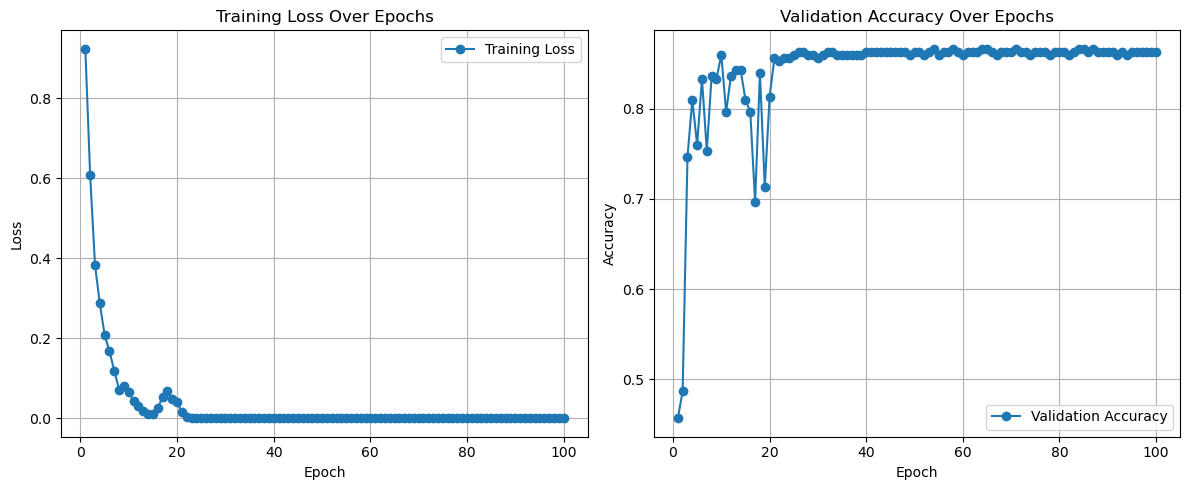

              precision    recall  f1-score   support

       Plane       0.92      0.86      0.89       100
        Ship       0.84      0.86      0.85       100
       Truck       0.83      0.87      0.85       100

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300

+------------------------------------------------------+
| Validation Loss: 0.6879, Validation Accuracy: 0.8633 |
+------------------------------------------------------+


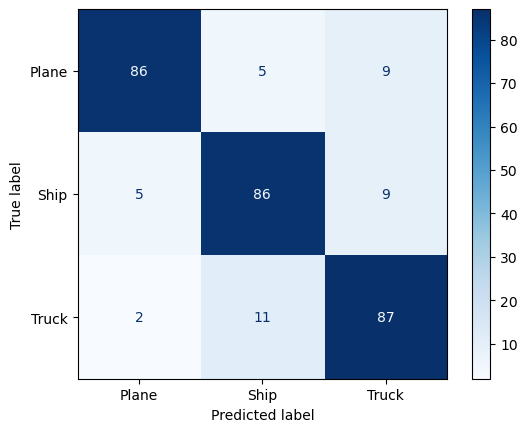

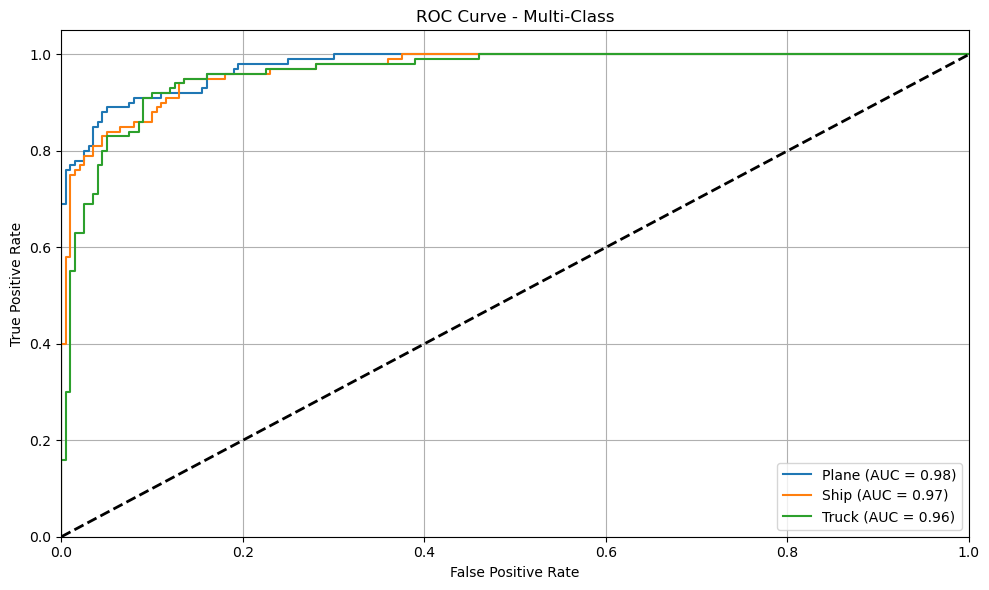

[ROC] Saved ROC plot to: plots/ROC_VGG11BN_2c_with_dropout_weightdecay_scheduler.png


In [6]:
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix
from src.utils import set_seed, print_framed_metrics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define experiment configurations
configs = [
    {
        "name": "VGG11BN_2a_no_dropout",
        "dropout": False,
        "weight_decay": 0,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2a_no_dropout_weightdecay_scheduler",
        "dropout": False,
        "weight_decay": 1e-4,
        "use_scheduler": True
    },
    {
        "name": "VGG11BN_2c_with_dropout",
        "dropout": True,
        "weight_decay": 0,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": False
    },
    {
        "name": "VGG11BN_2c_with_dropout_weightdecay_scheduler",
        "dropout": True,
        "weight_decay": 1e-4,
        "use_scheduler": True
    },
]

# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} ===")

    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=cfg["weight_decay"])

    scheduler = StepLR(optimizer, step_size=20, gamma=0.5) if cfg["use_scheduler"] else None

    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=cfg["name"]
    )


    # Evaluation
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    # Confusion matrix
    plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'], save_path=f"plots/{cfg['name']}_confusion_matrix.png")
    plot_multiclass_roc(
    model=trained_model,
    dataloader=dataloaders['val'],
    device=device,
    num_classes=3,
    class_names=['Plane', 'Ship', 'Truck'],
    model_name=cfg["name"]
    )